# Validation Notebook: Data Integrity + DeGroot Fit Checks

This notebook performs two checks:
1. Real-run data integrity audit for trajectory construction and message alignment.
2. Synthetic DeGroot recovery test (with noise) to validate fitting and evaluation logic.

In [1]:
from pathlib import Path
import numpy as np
import cvxpy as cp

from data_prep import (
    load_run_data,
    build_global_init_map,
    build_run_trajectory,
    build_neighbors_index,
    _numeric_agent_key,
    _bucket_events_to_slices,
    compute_required_time_slice_ms,
)
from plot_utils import (
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    calculate_mean_and_variance,
    compute_wasserstein_distance,
)

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])

PARAMS = {
    'stance_clip': (-1.0, 1.0),
    'rollout_horizon_cap': 20,
}

TARGET_AGENT_FRACTION = 0.4
CONSTRAIN_MESSAGES = 150

print('Project root:', ROOT)
print('Runs found:', len(RUN_DIRS))

Project root: /home/sammli/llm-network/modeling
Runs found: 27


In [2]:
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=TARGET_AGENT_FRACTION,
        return_post_mask=True,
        constrain_messages=CONSTRAIN_MESSAGES,
    )
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agents:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))

Global agents: 30
Global init priors available: 30


In [3]:
def _same_or_both_nan(a, b, atol=1e-10):
    if np.isnan(a) and np.isnan(b):
        return True
    return np.isclose(a, b, atol=atol)

def audit_run_trajectory_integrity(run_name, data, traj, post_mask, global_agent_ids, target_agent_fraction, constrain_messages):
    agent_index = {a: i for i, a in enumerate(global_agent_ids)}
    slice_ms = compute_required_time_slice_ms(len(global_agent_ids), target_agent_fraction=target_agent_fraction)

    events = sorted(data.get('message_events', []), key=lambda x: x[0])
    if constrain_messages is not None:
        events = events[:constrain_messages]

    rebucketed, last_slice = _bucket_events_to_slices(events, slice_ms)
    expected_T = int(last_slice)
    issues = []

    if traj.shape[0] != expected_T + 1:
        issues.append(f'shape mismatch: traj T={traj.shape[0]-1}, expected T={expected_T}')

    posted_value_mismatches = 0
    missing_post_flags = 0
    carry_forward_mismatches = 0
    init_seed_mismatches = 0
    init_missing_seed_count = 0
    scale_like_init_count = 0
    scale_values = np.array([-1.0, -0.5, 0.0, 0.5, 1.0], dtype=float)

    for t, obs in rebucketed.items():
        for aid, val in obs.items():
            if aid not in agent_index:
                continue
            i = agent_index[aid]
            if not post_mask[t, i]:
                missing_post_flags += 1
            if not np.isclose(traj[t, i], float(val), atol=1e-10):
                posted_value_mismatches += 1

    for t in range(1, traj.shape[0]):
        for i in range(traj.shape[1]):
            if post_mask[t, i]:
                continue
            if not _same_or_both_nan(traj[t, i], traj[t - 1, i]):
                carry_forward_mismatches += 1

    slice0_obs = rebucketed.get(0, {})
    for aid in global_agent_ids:
        i = agent_index[aid]
        if aid in slice0_obs:
            continue

        profile = data['profile_seed_by_slice'].get(aid, {})
        if not profile:
            init_missing_seed_count += 1
            continue

        t0 = min(profile)
        expected_init = float(profile[t0])
        actual_init = float(traj[0, i])

        if not np.isclose(actual_init, expected_init, atol=1e-10):
            init_seed_mismatches += 1

        if np.any(np.isclose(actual_init, scale_values, atol=1e-12)):
            # These values are allowed if they came from profile seed; we count for visibility only.
            scale_like_init_count += 1

    ok = (
        posted_value_mismatches == 0
        and missing_post_flags == 0
        and carry_forward_mismatches == 0
        and init_seed_mismatches == 0
        and init_missing_seed_count == 0
        and len(issues) == 0
    )

    return {
        'run_name': run_name,
        'ok': ok,
        'shape_issues': issues,
        'posted_value_mismatches': posted_value_mismatches,
        'missing_post_flags': missing_post_flags,
        'carry_forward_mismatches': carry_forward_mismatches,
        'init_seed_mismatches': init_seed_mismatches,
        'init_missing_seed_count': init_missing_seed_count,
        'scale_like_init_count': scale_like_init_count,
        'traj_shape': tuple(traj.shape),
        'expected_last_slice': expected_T,
    }

audit_results = []
for rn in sorted(RUN_TRAJ.keys()):
    result = audit_run_trajectory_integrity(
        rn,
        RUN_DATA[rn],
        np.asarray(RUN_TRAJ[rn], dtype=float),
        np.asarray(RUN_POST_MASK[rn], dtype=bool),
        GLOBAL_AGENT_IDS,
        TARGET_AGENT_FRACTION,
        CONSTRAIN_MESSAGES,
    )
    audit_results.append(result)

num_ok = sum(1 for r in audit_results if r['ok'])
print(f'Integrity audit: {num_ok}/{len(audit_results)} runs passed fully')

for r in audit_results[:10]:
    print(
        r['run_name'],
        'OK' if r['ok'] else 'FAIL',
        f"posted_mismatch={r['posted_value_mismatches']}",
        f"missing_post_flags={r['missing_post_flags']}",
        f"carry_forward_mismatch={r['carry_forward_mismatches']}",
        f"init_seed_mismatch={r['init_seed_mismatches']}",
        f"init_missing_seed={r['init_missing_seed_count']}",
        f"scale_like_init={r['scale_like_init_count']}",
    )

failing = [r for r in audit_results if not r['ok']]
if failing:
    print('\nFirst failing run details:')
    print(failing[0])
else:
    print('\nAll runs passed integrity checks.')

Integrity audit: 27/27 runs passed fully
run_20260320-130058 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-133304 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-140500 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-143643 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-150827 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-154019 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatch=0 init_seed_mismatch=0 init_missing_seed=0 scale_like_init=0
run_20260320-161210 OK posted_mismatch=0 missing_post_flags=0 carry_forward_mismatc

## Synthetic DeGroot Recovery Test

This section uses a known true DeGroot matrix to generate noisy synthetic trajectories,
then re-fits the matrix with the same fitting logic and checks recovery quality.

In [4]:
def build_dataset_from_run(run):
    X = []
    Y = []
    for t in range(len(run) - 1):
        X.append(run[t])
        Y.append(run[t + 1])
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    return X, Y

def fit_row_stochastic_W_from_pooled_runs(run_traj_map, run_neighbors):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for run_name in run_names[1:]:
        if run_neighbors[run_name] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    X_blocks = []
    Y_blocks = []
    for run_name in run_names:
        X, Y = build_dataset_from_run(np.asarray(run_traj_map[run_name], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)

    n = X_pool.shape[1]
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        ns = ref_neighbors[i]
        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]

        w_ns = cp.Variable(len(ns))
        objective = cp.Minimize(cp.sum_squares(X_ns @ w_ns - y))
        constraints = [w_ns >= 0, cp.sum(w_ns) == 1]
        problem = cp.Problem(objective, constraints)
        problem.solve()

        row = np.zeros(n, dtype=float)
        row[ns] = np.asarray(w_ns.value, dtype=float).ravel()
        W[i] = row

    return W, X_pool, Y_pool

def degroot_rollout_prediction(W, x0, horizon):
    predictions = [x0]
    current_x = x0.copy()
    for t in range(horizon):
        current_x = W @ current_x
        predictions.append(current_x.copy())
    return predictions

Synthetic recovery summary
  Relative Frobenius error on W: 0.014672
  One-step pooled MSE: 9.712e-05
  Avg flattened corr(obs, pred): 0.996021
  Avg Wasserstein(obs, pred): 0.007973


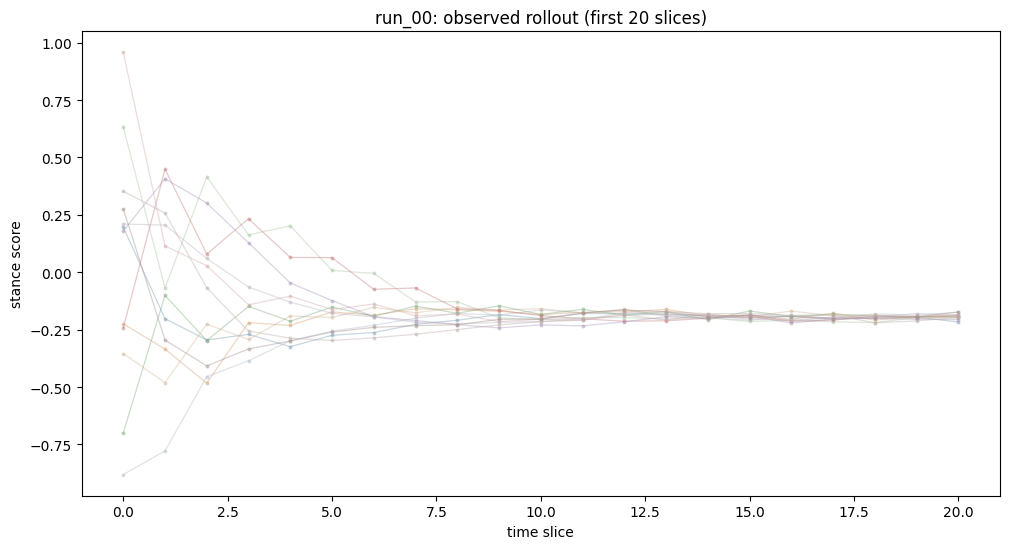

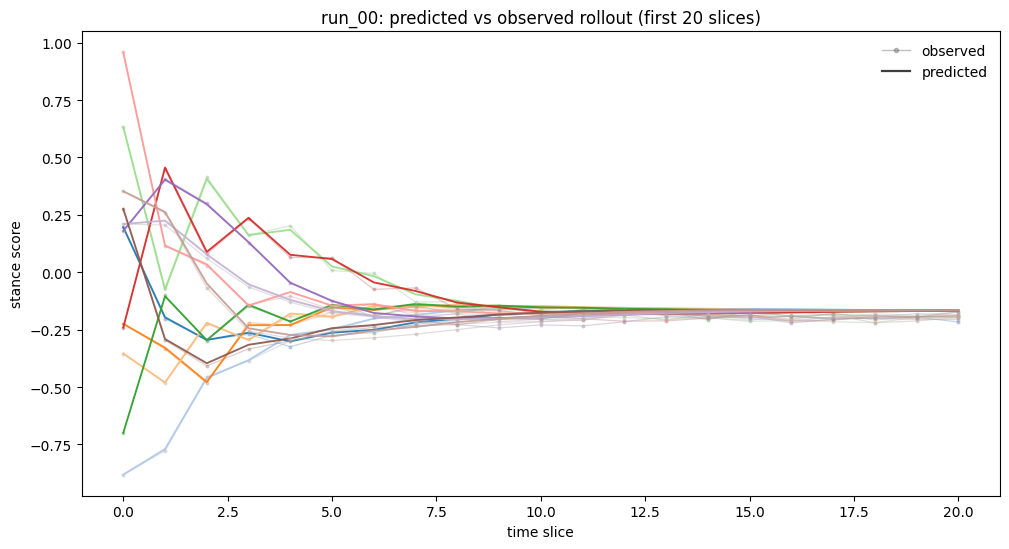

Sample run metrics: {'run': 'run_00', 'steady_mean_obs': -0.19534464666186435, 'steady_mean_pred': -0.16660762418307243, 'steady_var_obs': 0.00012184953488691578, 'steady_var_pred': 1.998643926975903e-06, 'wasserstein': 0.018619916183751854, 'corr': 0.9967678947697551}


In [5]:
rng = np.random.default_rng(7)
n_agents = 12
n_runs = 10
horizon = PARAMS['rollout_horizon_cap']
noise_std = 0.01

synthetic_neighbors = {}
for i in range(n_agents):
    base = {(i - 1) % n_agents, i, (i + 1) % n_agents}
    extra = {(i + 3) % n_agents}
    ns = sorted(base | extra)
    synthetic_neighbors[i] = ns

W_true = np.zeros((n_agents, n_agents), dtype=float)
for i in range(n_agents):
    ns = synthetic_neighbors[i]
    w = rng.dirichlet(np.ones(len(ns)))
    W_true[i, ns] = w

SYN_RUN_TRAJ = {}
for r in range(n_runs):
    x = rng.uniform(-1.0, 1.0, size=n_agents)
    states = [x.copy()]
    for _ in range(horizon):
        x_next = W_true @ x
        x_next = np.clip(x_next + rng.normal(0.0, noise_std, size=n_agents), -1.0, 1.0)
        states.append(x_next.copy())
        x = x_next
    SYN_RUN_TRAJ[f'run_{r:02d}'] = np.asarray(states, dtype=float)

SYN_NEIGHBORS_BY_RUN = {rn: synthetic_neighbors for rn in SYN_RUN_TRAJ.keys()}

W_hat, X_pool, Y_pool = fit_row_stochastic_W_from_pooled_runs(SYN_RUN_TRAJ, SYN_NEIGHBORS_BY_RUN)
PRED_SYN = {rn: np.asarray(degroot_rollout_prediction(W_hat, tr[0], horizon), dtype=float) for rn, tr in SYN_RUN_TRAJ.items()}

fro_rel_err = float(np.linalg.norm(W_hat - W_true) / np.linalg.norm(W_true))
one_step_mse = float(np.mean((Y_pool - X_pool @ W_hat.T) ** 2))

metric_rows = []
for rn in sorted(SYN_RUN_TRAJ.keys()):
    obs = np.asarray(SYN_RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PRED_SYN[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]

    mv = calculate_mean_and_variance(obs, pred, last_n=3)
    wd = compute_wasserstein_distance(obs, pred)
    corr = float(np.corrcoef(obs.ravel(), pred.ravel())[0, 1])

    metric_rows.append({
        'run': rn,
        'steady_mean_obs': mv['steady_mean_obs'],
        'steady_mean_pred': mv['steady_mean_pred'],
        'steady_var_obs': mv['steady_var_obs'],
        'steady_var_pred': mv['steady_var_pred'],
        'wasserstein': wd,
        'corr': corr,
    })

avg_corr = float(np.mean([m['corr'] for m in metric_rows]))
avg_wd = float(np.mean([m['wasserstein'] for m in metric_rows]))

print('Synthetic recovery summary')
print('  Relative Frobenius error on W:', round(fro_rel_err, 6))
print('  One-step pooled MSE:', round(one_step_mse, 8))
print('  Avg flattened corr(obs, pred):', round(avg_corr, 6))
print('  Avg Wasserstein(obs, pred):', round(avg_wd, 6))

sample_run = sorted(SYN_RUN_TRAJ.keys())[0]
plot_observed_trajectories(sample_run, SYN_RUN_TRAJ[sample_run], list(range(n_agents)), horizon)
plot_predicted_vs_observed(sample_run, SYN_RUN_TRAJ[sample_run], PRED_SYN[sample_run], list(range(n_agents)), horizon)

print('Sample run metrics:', metric_rows[0])